In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\projects\\360° Customer Intelligence and Business Growth Analytics\\E-commerce Customer Behavior - Sheet1.csv")

In [5]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [6]:
print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [8]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [9]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

#1. Which membership type spends the most money?

In [11]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral


Membership Type
Bronze     54913.1
Gold      153403.9
Silver     87566.6
Name: Total Spend, dtype: float64


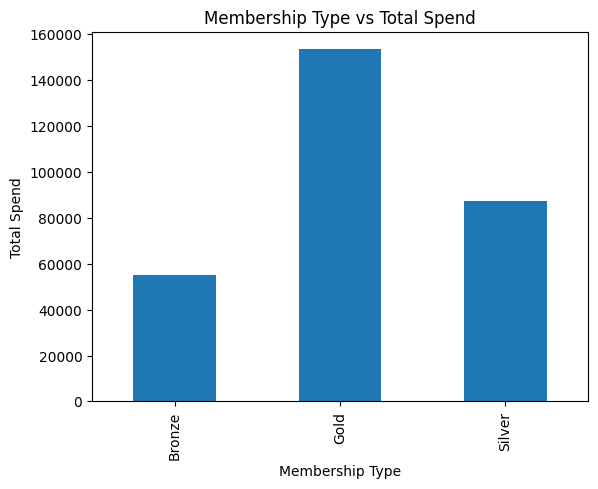

In [12]:
membership_spend = df.groupby('Membership Type')['Total Spend'].sum()

print(membership_spend)
membership_spend.plot(kind='bar')
plt.title('Membership Type vs Total Spend')
plt.xlabel('Membership Type')
plt.ylabel('Total Spend')
plt.show()

#2. Which city generates the highest revenue?

In [13]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral


City
San Francisco    84666.8
New York         68737.1
Los Angeles      47524.0
Miami            40042.6
Chicago          28993.2
Houston          25919.9
Name: Total Spend, dtype: float64


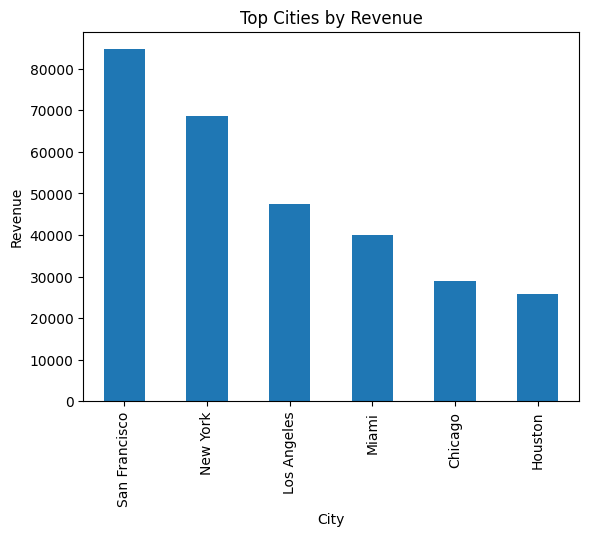

In [14]:
city_sales = df.groupby('City')['Total Spend'].sum().sort_values(ascending=False)

print(city_sales)
city_sales.head(10).plot(kind='bar')
plt.title('Top Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.show()

#3. Does discount applied increase purchases?

In [15]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral


Discount Applied
False    13.074286
True     12.125714
Name: Items Purchased, dtype: float64


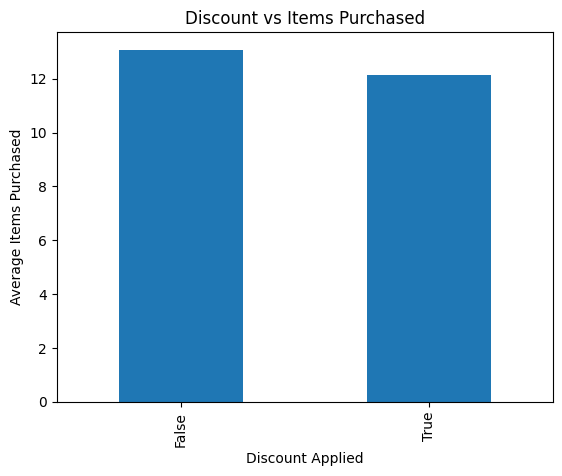

In [16]:
comparison = df.groupby('Discount Applied')['Items Purchased'].mean()
print(comparison)

comparison.plot(kind='bar')
plt.title('Discount vs Items Purchased')
plt.xlabel('Discount Applied')
plt.ylabel('Average Items Purchased')
plt.show()

### City-wise Discount Applied vs. Items Purchased

Discount Applied      False      True 
City                                  
Chicago                 NaN   9.413793
Houston            7.568966        NaN
Los Angeles       11.677966        NaN
Miami                   NaN  11.637931
New York                NaN  15.271186
San Francisco     20.000000        NaN


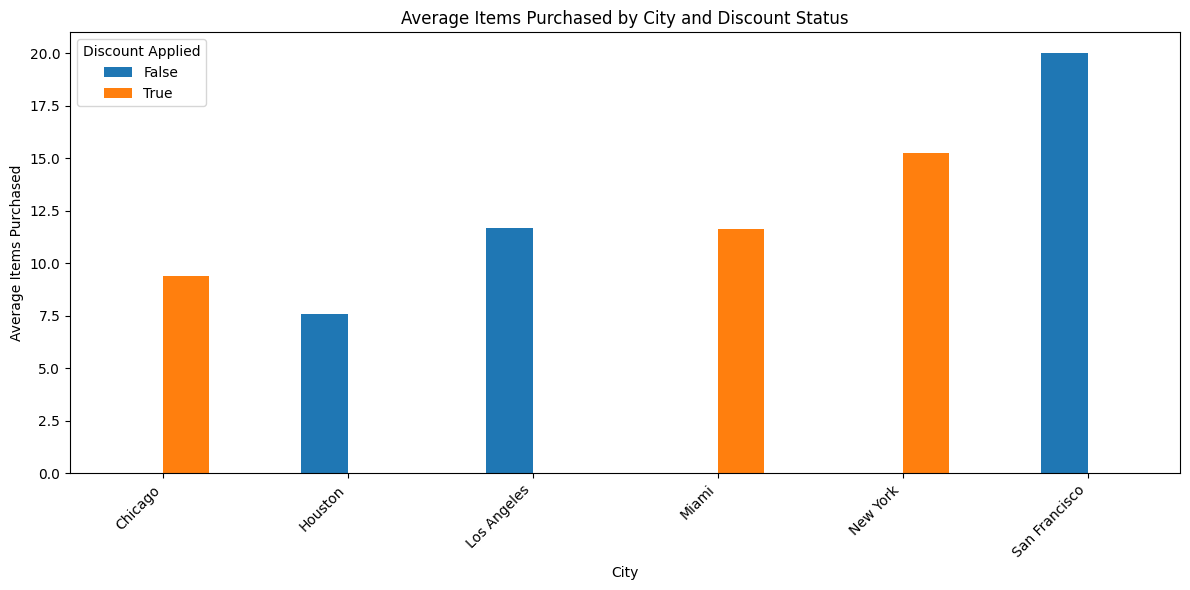

In [17]:
city_discount_comparison = df.groupby(['City', 'Discount Applied'])['Items Purchased'].mean().unstack()

print(city_discount_comparison)

city_discount_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Average Items Purchased by City and Discount Status')
plt.xlabel('City')
plt.ylabel('Average Items Purchased')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Discount Applied')
plt.tight_layout()
plt.show()

#4. Which age group spends the most?

In [18]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


C:\Users\Admin\AppData\Local\Temp\ipykernel_20452\4238850963.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = df.groupby('Age Group')['Total Spend'].mean()


Age Group
18-25            NaN
26-35    1025.642308
36-45     481.752586
46+              NaN
Name: Total Spend, dtype: float64


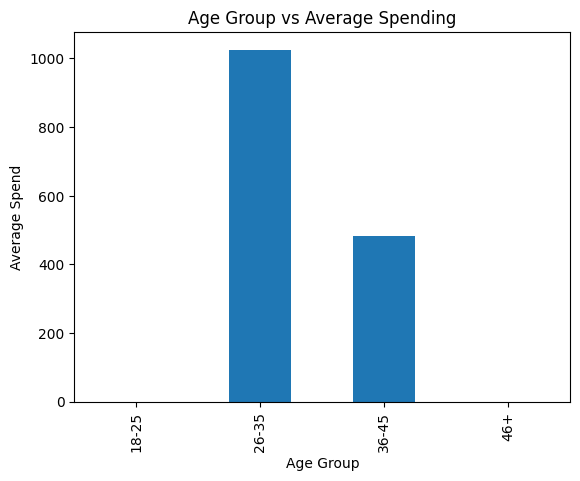

In [19]:
bins = [18,25,35,45,60]
labels = ['18-25','26-35','36-45','46+']
# Create Age Group Column

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_spend = df.groupby('Age Group')['Total Spend'].mean()
print(age_spend)


age_spend.plot(kind='bar')
plt.title('Age Group vs Average Spending')
plt.xlabel('Age Group')
plt.ylabel('Average Spend')
plt.show()

#5. Is customer satisfaction related to average ratings?

In [20]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


Satisfaction Level
Neutral        3.655140
Satisfied      4.646400
Unsatisfied    3.692241
Name: Average Rating, dtype: float64


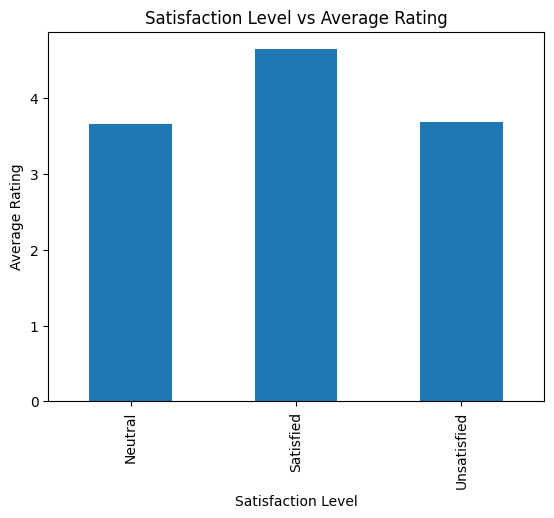

In [21]:
satisfaction_rating = df.groupby('Satisfaction Level')['Average Rating'].mean()
print(satisfaction_rating)
satisfaction_rating.plot(kind='bar')


plt.title('Satisfaction Level vs Average Rating')
plt.xlabel('Satisfaction Level')
plt.ylabel('Average Rating')
plt.show()

#6. Which membership type has the highest customer satisfaction?

In [22]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,26-35
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,36-45
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,26-35
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,26-35


Satisfaction Level  Neutral  Satisfied  Unsatisfied
Membership Type                                    
Bronze                   56          0           58
Gold                      0        117            0
Silver                   51          8           58


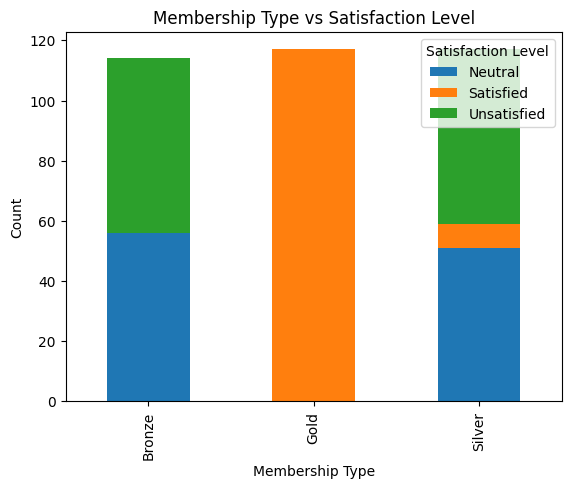

In [23]:
membership_satisfaction = pd.crosstab(
df['Membership Type'],
df['Satisfaction Level']
)

print(membership_satisfaction)
membership_satisfaction.plot(kind='bar', stacked=True)
plt.title('Membership Type vs Satisfaction Level')
plt.xlabel('Membership Type')
plt.ylabel('Count')
plt.show()

#7. How does recency affect customer spending?

In [24]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,26-35
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,36-45
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,26-35
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,26-35


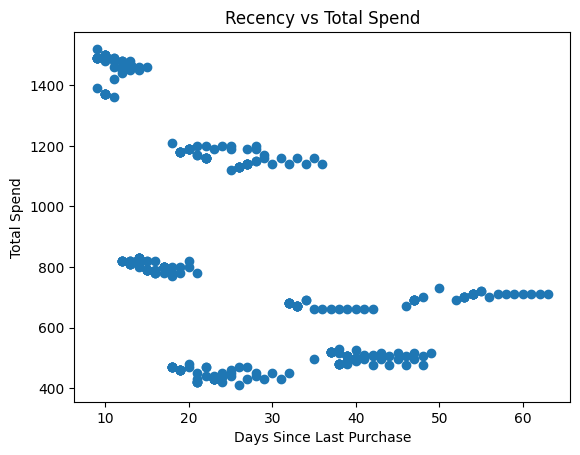

In [25]:
plt.scatter(
df['Days Since Last Purchase'],
df['Total Spend']

)
plt.title('Recency vs Total Spend')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Total Spend')
plt.show()

#8. Which gender spends more on average?

Gender
Female    703.828571
Male      986.934857
Name: Total Spend, dtype: float64


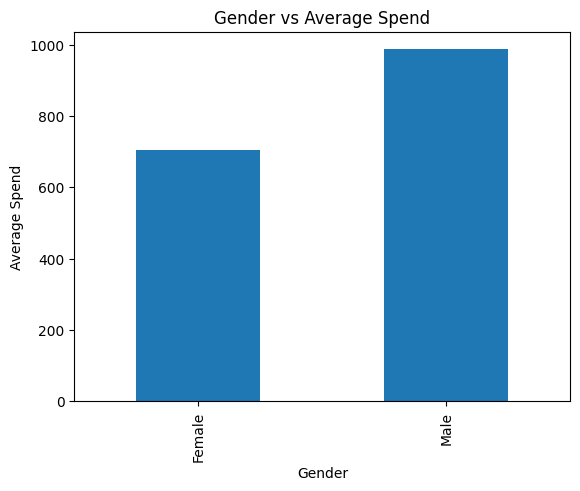

In [26]:
gender_spend = df.groupby('Gender')['Total Spend'].mean()
print(gender_spend)
gender_spend.plot(kind='bar')
plt.title('Gender vs Average Spend')
plt.xlabel('Gender')
plt.ylabel('Average Spend')
plt.show()

#9. Which customers are likely to churn?

In [27]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


In [28]:
churn_customers = df[
(df['Days Since Last Purchase'] > 40) &
(df['Satisfaction Level'] == 'Unsatisfied')
]
churn_customers.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,36-45
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,26-35
16,117,Male,26,Miami,Silver,700.60,12,3.7,True,48,Unsatisfied,26-35
20,121,Female,43,Chicago,Bronze,505.75,10,3.3,True,41,Unsatisfied,36-45
22,123,Male,27,Miami,Silver,710.40,13,4.1,True,54,Unsatisfied,26-35


#10. Which factors affect customer retention most?

In [29]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


                          Customer ID       Age  Total Spend  Items Purchased  \
Customer ID                  1.000000  0.011171    -0.006316        -0.003230   
Age                          0.011171  1.000000    -0.677918        -0.685274   
Total Spend                 -0.006316 -0.677918     1.000000         0.972425   
Items Purchased             -0.003230 -0.685274     0.972425         1.000000   
Average Rating              -0.000510 -0.722277     0.941475         0.922028   
Discount Applied            -0.000707  0.056979    -0.160723        -0.114285   
Days Since Last Purchase     0.117940  0.168763    -0.540089        -0.420393   

                          Average Rating  Discount Applied  \
Customer ID                    -0.000510         -0.000707   
Age                            -0.722277          0.056979   
Total Spend                     0.941475         -0.160723   
Items Purchased                 0.922028         -0.114285   
Average Rating                  1.000000 

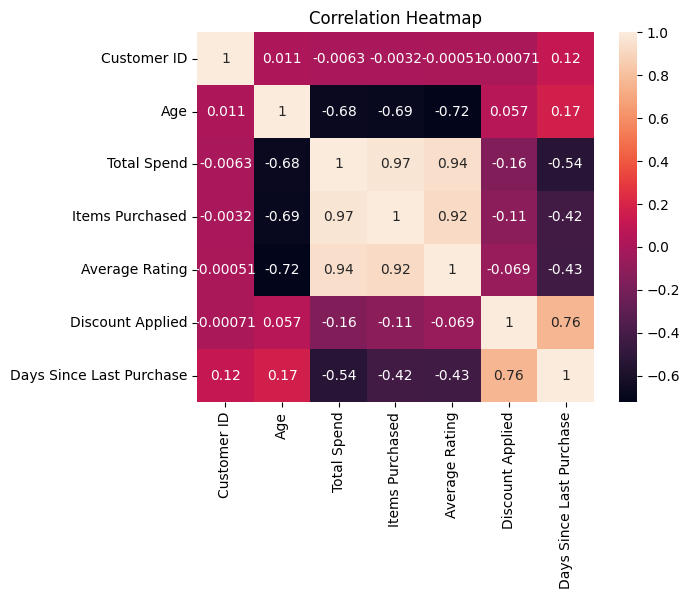

In [30]:
correlation = df.corr(numeric_only=True)
print(correlation)
sns.heatmap(correlation, annot=True)
plt.title('Correlation Heatmap')
plt.show()

#Social Media Sentiment & Brand Analysis

#11. What percentage of comments are positive?




In [31]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


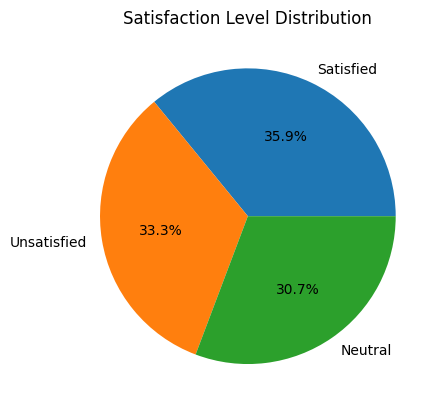

In [32]:
sentiment_count = df['Satisfaction Level'].value_counts()
print(sentiment_count)
sentiment_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Satisfaction Level Distribution')
plt.ylabel('')
plt.show()

#Marketing Funnel Analysis

#13. What is the conversion rate?

In [33]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


In [34]:
total_items_purchased = df['Items Purchased'].sum()
total_customers = df['Customer ID'].nunique()

# Calculate conversion rate as items purchased per customer
conversion_rate = (total_items_purchased / total_customers) * 100

print('Conversion Rate (Items Purchased per Customer):', conversion_rate)

Conversion Rate (Items Purchased per Customer): 1260.0


#Product Performance & Feature Adoption Analysis


#15. Which products are most popular?

In [35]:
df.head(2)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Age Group
0,101,Female,29,New York,Gold,1120.2,14,4.6,True,25,Satisfied,26-35
1,102,Male,34,Los Angeles,Silver,780.5,11,4.1,False,18,Neutral,26-35


City
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64


Text(0.5, 0, 'Product Category')

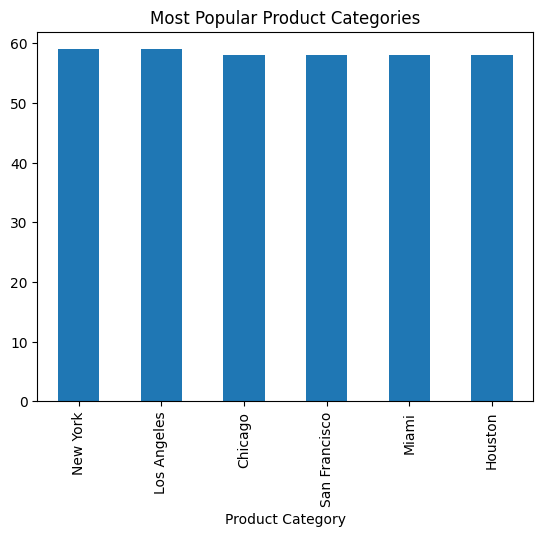

In [36]:
popular_products = df['City'].value_counts()
print(popular_products)
popular_products.plot(kind='bar')
plt.title('Most Popular Product Categories')
plt.xlabel('Product Category')